# Machine Learning Data Prepreparation

This notebook provides necessary steps to prepare the data for machine learning modelling.

This notebook includes the following: 
- Log-transformation of the gnomAD_AF column 
- Drop redundant columns 
- Map target to binary numbers (0 and 1) 
- Split data into X and y
- Split data into training and test (X_train, X_test, y_train, y_test) 
- Identify outliers using Z-score 
- Save new dataframes 

## Import Libraries

In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split

## Import Preprocessed Data 

In [18]:
input_file = "data/processed_variants_for_EDA.tsv"

ml_data = pd.read_csv(input_file, sep="\t", low_memory=False) 
print(f"Loaded {len(ml_data)} variants.")
display(ml_data.head())

Loaded 1906 variants.


,Hugo_Symbol,Consequence,Variant_Type,MUTATION_EFFECT,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,is_null_variant,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC
0,MAPK1,missense_variant,SNP,Likely Loss-of-function,0.000000,False,1.000,0.01,False,True,1,False,0,False,False,True,False,Likely Neutral
1,BRCA1,missense_variant,SNP,Loss-of-function,0.000000,False,0.344,0.00,False,False,0,False,0,False,True,False,False,Oncogenic
2,BRCA1,missense_variant,SNP,Loss-of-function,0.000032,True,0.026,0.00,False,True,1,False,0,False,True,False,False,Oncogenic
3,TP53,missense_variant,SNP,Loss-of-function,0.000000,False,0.396,0.12,True,True,1,True,2,False,True,True,False,Oncogenic
4,TP53,missense_variant,SNP,Likely Loss-of-function,0.000000,False,0.838,0.02,True,True,1,True,1,False,True,True,False,Oncogenic


## Log-Transform gnomAD_AF

### Visualize before transformation 

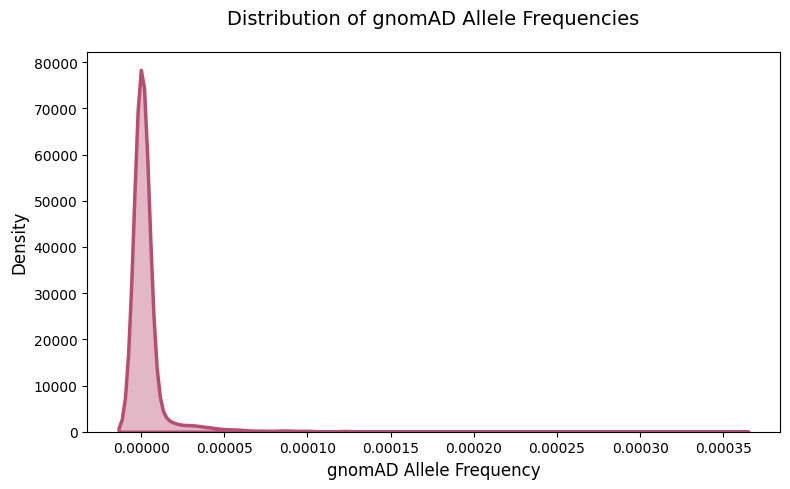

In [19]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF', 
            data=ml_data,
            color="#b74d71",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies', fontsize=14, pad=20)
plt.xlabel('gnomAD Allele Frequency', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.savefig("plots/gnomad_distribution.png", dpi=300)
plt.show()


### Transform data

In [20]:
epsilon = 1e-6
ml_data['gnomAD_AF_log'] = np.log10(ml_data['gnomAD_AF'] + epsilon)

### Visualize after transformation 

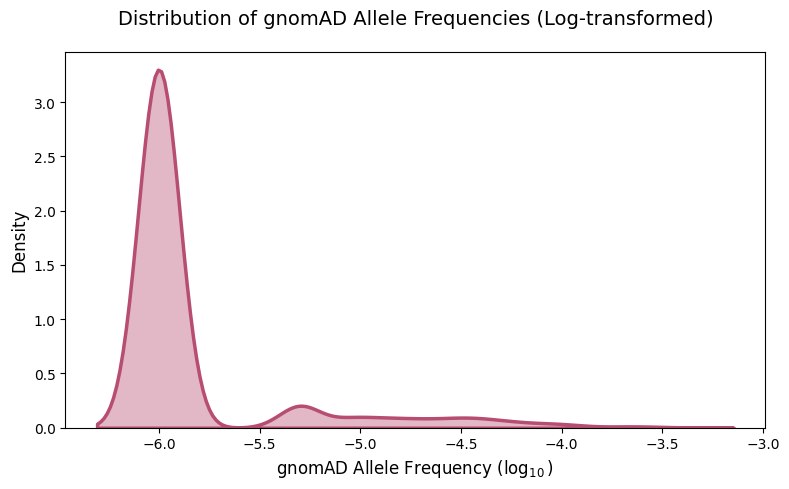

In [21]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF_log', 
            data=ml_data,
            color="#b74d71",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies (Log-transformed)', fontsize=14, pad=20)
plt.xlabel(r'gnomAD Allele Frequency ($\log_{10}$)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.savefig("plots/gnomad_log_distribution.png", dpi=300)
plt.show()


### Drop gnomAD_AF Column

In [22]:
ml_data = ml_data.drop('gnomAD_AF', axis=1)
display(ml_data.head())

,Hugo_Symbol,Consequence,Variant_Type,MUTATION_EFFECT,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,is_null_variant,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC,gnomAD_AF_log
0,MAPK1,missense_variant,SNP,Likely Loss-of-function,False,1.000,0.01,False,True,1,False,0,False,False,True,False,Likely Neutral,-6.000000
1,BRCA1,missense_variant,SNP,Loss-of-function,False,0.344,0.00,False,False,0,False,0,False,True,False,False,Oncogenic,-6.000000
2,BRCA1,missense_variant,SNP,Loss-of-function,True,0.026,0.00,False,True,1,False,0,False,True,False,False,Oncogenic,-4.482754
3,TP53,missense_variant,SNP,Loss-of-function,False,0.396,0.12,True,True,1,True,2,False,True,True,False,Oncogenic,-6.000000
4,TP53,missense_variant,SNP,Likely Loss-of-function,False,0.838,0.02,True,True,1,True,1,False,True,True,False,Oncogenic,-6.000000


### Drop MUTATION_EFFECT Column

In [23]:
ml_data = ml_data.drop('MUTATION_EFFECT', axis=1)
display(ml_data.head())

,Hugo_Symbol,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,is_null_variant,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC,gnomAD_AF_log
0,MAPK1,missense_variant,SNP,False,1.000,0.01,False,True,1,False,0,False,False,True,False,Likely Neutral,-6.000000
1,BRCA1,missense_variant,SNP,False,0.344,0.00,False,False,0,False,0,False,True,False,False,Oncogenic,-6.000000
2,BRCA1,missense_variant,SNP,True,0.026,0.00,False,True,1,False,0,False,True,False,False,Oncogenic,-4.482754
3,TP53,missense_variant,SNP,False,0.396,0.12,True,True,1,True,2,False,True,True,False,Oncogenic,-6.000000
4,TP53,missense_variant,SNP,False,0.838,0.02,True,True,1,True,1,False,True,True,False,Oncogenic,-6.000000


### Drop is_null_variant Column

In [24]:
ml_data = ml_data.drop('is_null_variant', axis=1)
display(ml_data.head())

,Hugo_Symbol,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC,gnomAD_AF_log
0,MAPK1,missense_variant,SNP,False,1.000,0.01,False,True,1,False,0,False,True,False,Likely Neutral,-6.000000
1,BRCA1,missense_variant,SNP,False,0.344,0.00,False,False,0,False,0,True,False,False,Oncogenic,-6.000000
2,BRCA1,missense_variant,SNP,True,0.026,0.00,False,True,1,False,0,True,False,False,Oncogenic,-4.482754
3,TP53,missense_variant,SNP,False,0.396,0.12,True,True,1,True,2,True,True,False,Oncogenic,-6.000000
4,TP53,missense_variant,SNP,False,0.838,0.02,True,True,1,True,1,True,True,False,Oncogenic,-6.000000


## Map Target to Binary Numbers (1 = "Oncogenic", 0 = "Likely Neutral")

In [25]:
target_map = {'Oncogenic': 1, 'Likely Neutral': 0}
ml_data['TARGET'] = ml_data['ONCOGENIC'].map(target_map)

## Split Data into X (features) and Y (target) 

In [26]:
X = ml_data.drop(['ONCOGENIC', 'TARGET'], axis=1)
y = ml_data['TARGET']

## Split Data into Training and Test

In [27]:
# use stratified sampling for balanced splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Identify Outliers Using Z-score

In [28]:
# Detect outliers using z-scores 

# Compute Z-scores for numeric columns
z_scores = (X_train.select_dtypes(include=[np.number]) - X_train.mean(numeric_only=True)) / X_train.std(numeric_only=True)

# Identify Outliers (absolute Z-score > 3)
outliers = (np.abs(z_scores) > 3)

# Count total outliers
num_outliers = outliers.sum().sum()

print(f"Total number of outliers: {num_outliers}")

Total number of outliers: 100


In [29]:
# Outliers per feature
print("Outliers per feature:")
print(outliers.sum().sort_values(ascending=False))

Outliers per feature:
gnomAD_AF_log        54
SIFT_Score           33
n_func_sites         13
IN_DOMAIN             0
Polyphen_Score        0
In_Hotspot            0
IN_FUNC_SITE          0
has_gnomAD_AF         0
is_null_var_tsg       0
n_protein_domains     0
ncg_oncogene          0
ncg_tsg               0
dtype: int64


In [30]:
for col in ['gnomAD_AF_log', 'SIFT_Score', 'n_func_sites']:
    print(f"\n{col} outliers:")
    print(X_train[col][outliers[col]].sort_values())


gnomAD_AF_log outliers:
837    -4.389680
140    -4.389626
786    -4.389437
733    -4.389006
433    -4.388986
1433   -4.388617
1014   -4.387711
393    -4.386008
949    -4.349220
383    -4.348889
1102   -4.348672
1374   -4.343770
797    -4.342540
872    -4.339103
668    -4.312261
695    -4.308495
360    -4.278165
731    -4.277697
495    -4.277635
690    -4.275393
391    -4.264468
403    -4.246467
1772   -4.246253
879    -4.216960
777    -4.216562
507    -4.216341
371    -4.212666
509    -4.211170
564    -4.163289
919    -4.162064
847    -4.138462
1005   -4.136396
562    -4.114564
382    -4.110571
653    -4.072462
728    -4.071925
1476   -4.054496
849    -4.047600
317    -4.036935
1565   -4.033591
359    -3.997888
624    -3.997457
136    -3.996788
205    -3.949473
357    -3.918912
415    -3.905043
463    -3.903970
448    -3.900741
1389   -3.725999
1310   -3.698931
431    -3.657402
411    -3.606234
537    -3.597685
176    -3.452680
Name: gnomAD_AF_log, dtype: float64

SIFT_Score outliers:

The outliers are kept in the dataset, since they reflect genuine biological variation. 

## Save Processed Dataset for Machine Learning Modeling

In [31]:
# Save feature data 
X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)

# Save target data
y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)

print("Dataframes successfully saved!🥳") 

Dataframes successfully saved!🥳
